<a href="https://colab.research.google.com/github/Thilan67/PlayerTrackingInSports/blob/main/ProgrammingAssignment2_DTS2409.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Thu Jun 25 06:53:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Install necessary libraries
!pip install ultralytics roboflow opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 142.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18


In [3]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [4]:
from roboflow import Roboflow
from google.colab import userdata
from IPython.display import Image

In [5]:
from roboflow import Roboflow
from roboflow import Roboflow
from google.colab import userdata

api_key = userdata.get("ROBOFLOW_API_KEY")

rf = Roboflow(api_key=api_key)
project = rf.workspace("aiwiththilan").project("detectplayers-0hxtm")
version = project.version(3)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to DetectPlayers-3 in yolov8:: 100%|██████████| 310/310 [00:00<00:00, 2199.63it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [51]:
import os
import yaml

# Fix the paths in your data.yaml
yaml_path = f'{dataset.location}/data.yaml'

with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

print("Before fixing:")
print(f"Train: {data_config['train']}")
print(f"Val: {data_config['val']}")

# Update to correct paths for YOUR dataset
data_config['train'] = f'{dataset.location}/train/images'
data_config['val'] = f'{dataset.location}/valid/images'

# Only include test if the directory exists
test_path = f'{dataset.location}/test/images'
if os.path.exists(test_path):
    data_config['test'] = test_path
elif 'test' in data_config:
    del data_config['test']

# Save the corrected data.yaml
with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f)

print("\nAfter fixing:")
print(f"Train: {data_config['train']}")
print(f"Val: {data_config['val']}")
print(f"Test: {data_config.get('test', 'Not included')}")

# Verify the corrected paths exist
print("\nCorrected path verification:")
print(f"Train path exists: {os.path.exists(data_config['train'])}")
print(f"Val path exists: {os.path.exists(data_config['val'])}")

Before fixing:
Train: /content/DetectPlayers-3/train/images
Val: /content/DetectPlayers-3/valid/images

After fixing:
Train: /content/DetectPlayers-3/train/images
Val: /content/DetectPlayers-3/valid/images
Test: /content/DetectPlayers-3/test/images

Corrected path verification:
Train path exists: True
Val path exists: True


In [7]:
%cd {HOME}

# Use smaller model and resolution
!yolo task=detect mode=train model=yolov8s.pt data={dataset.location}/data.yaml batch=16 epochs=50 imgsz=640 plots=True

/content
Ultralytics 8.4.77 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/DetectPlayers-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optim

/content

Confusion Matrix:


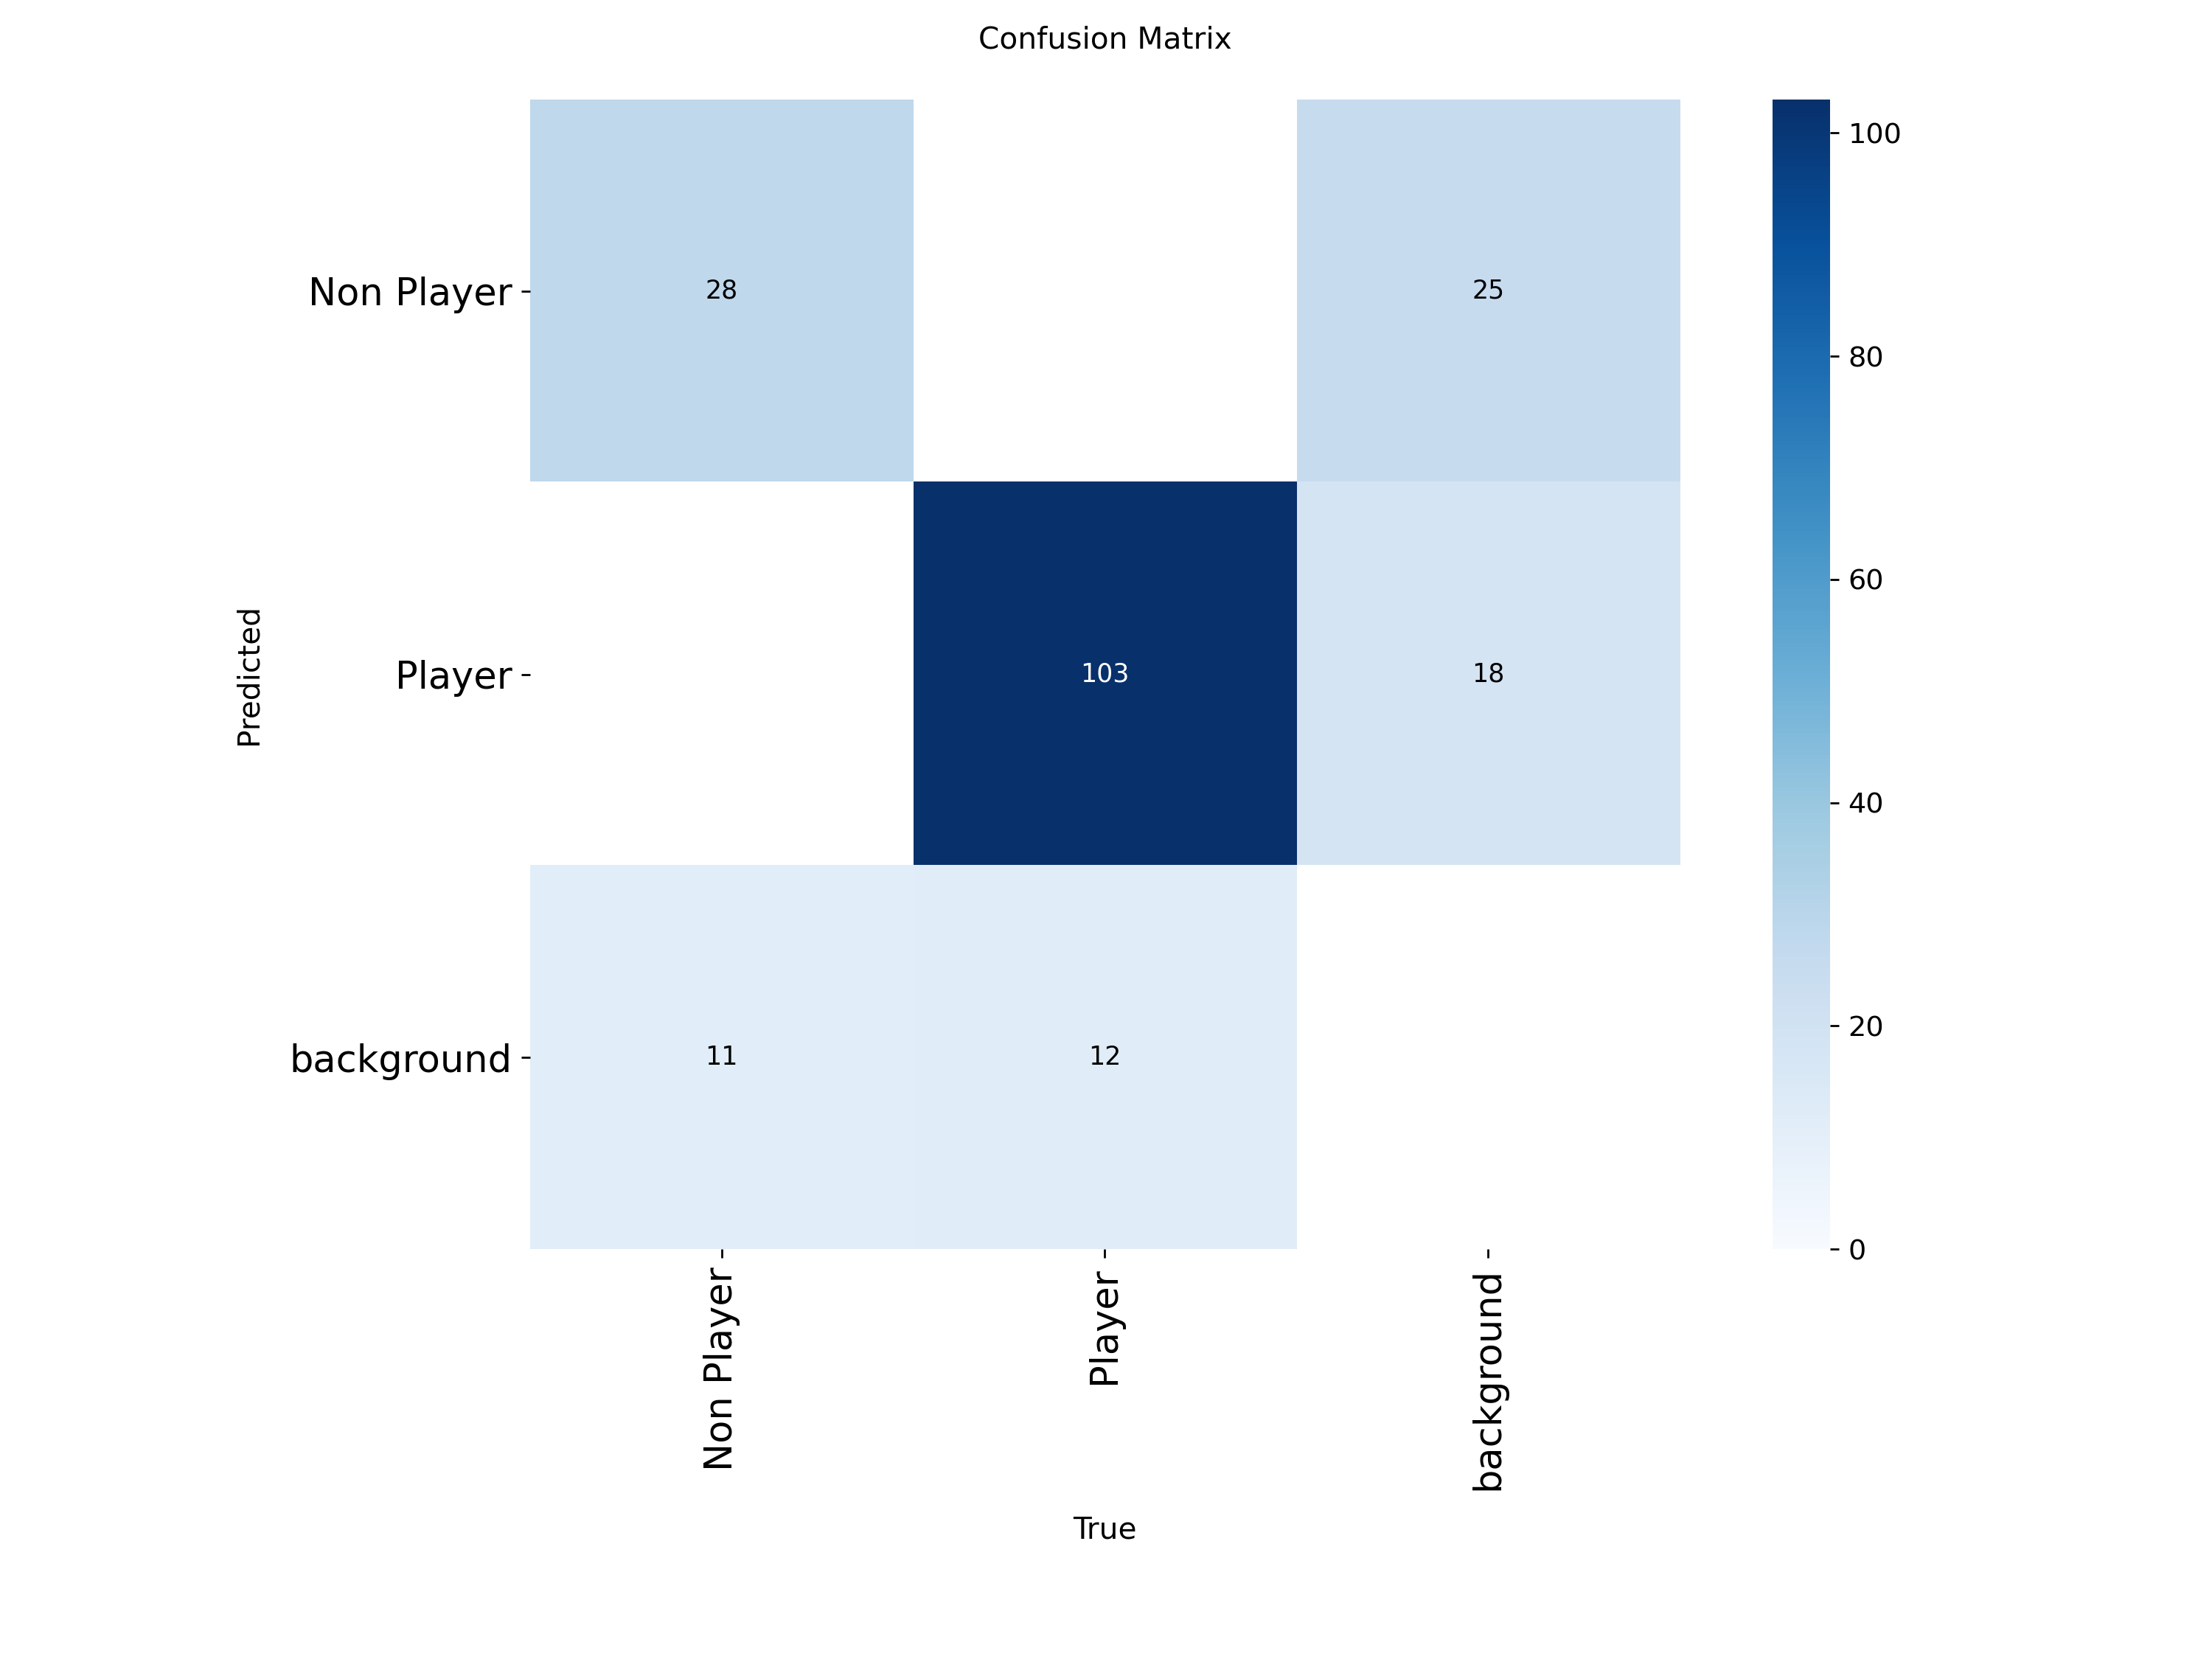


Training Metrics:


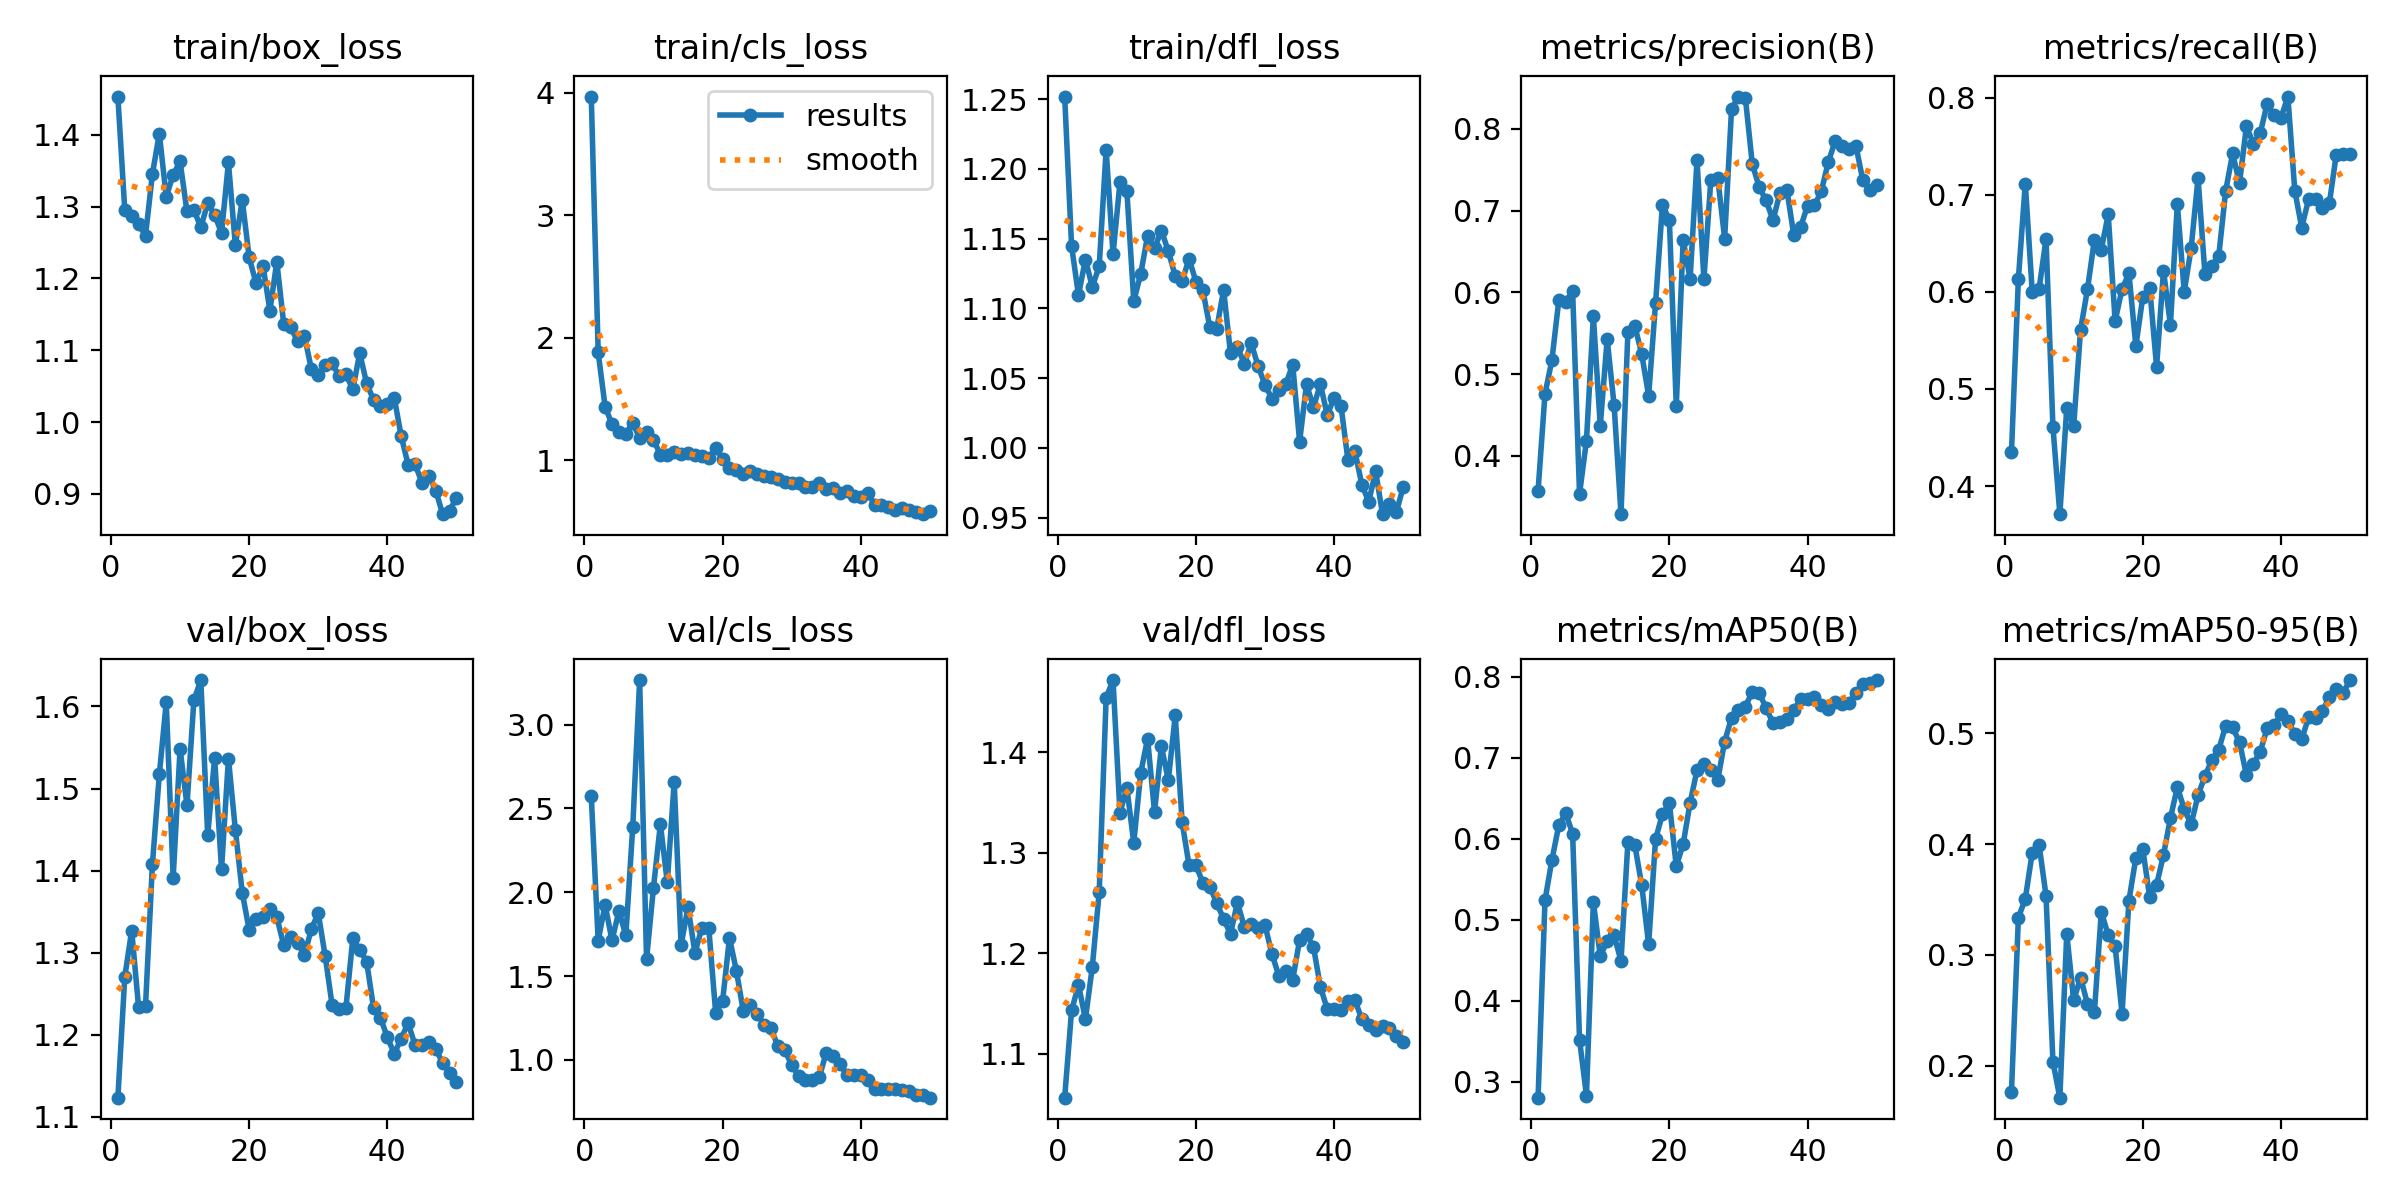


Sample Predictions:


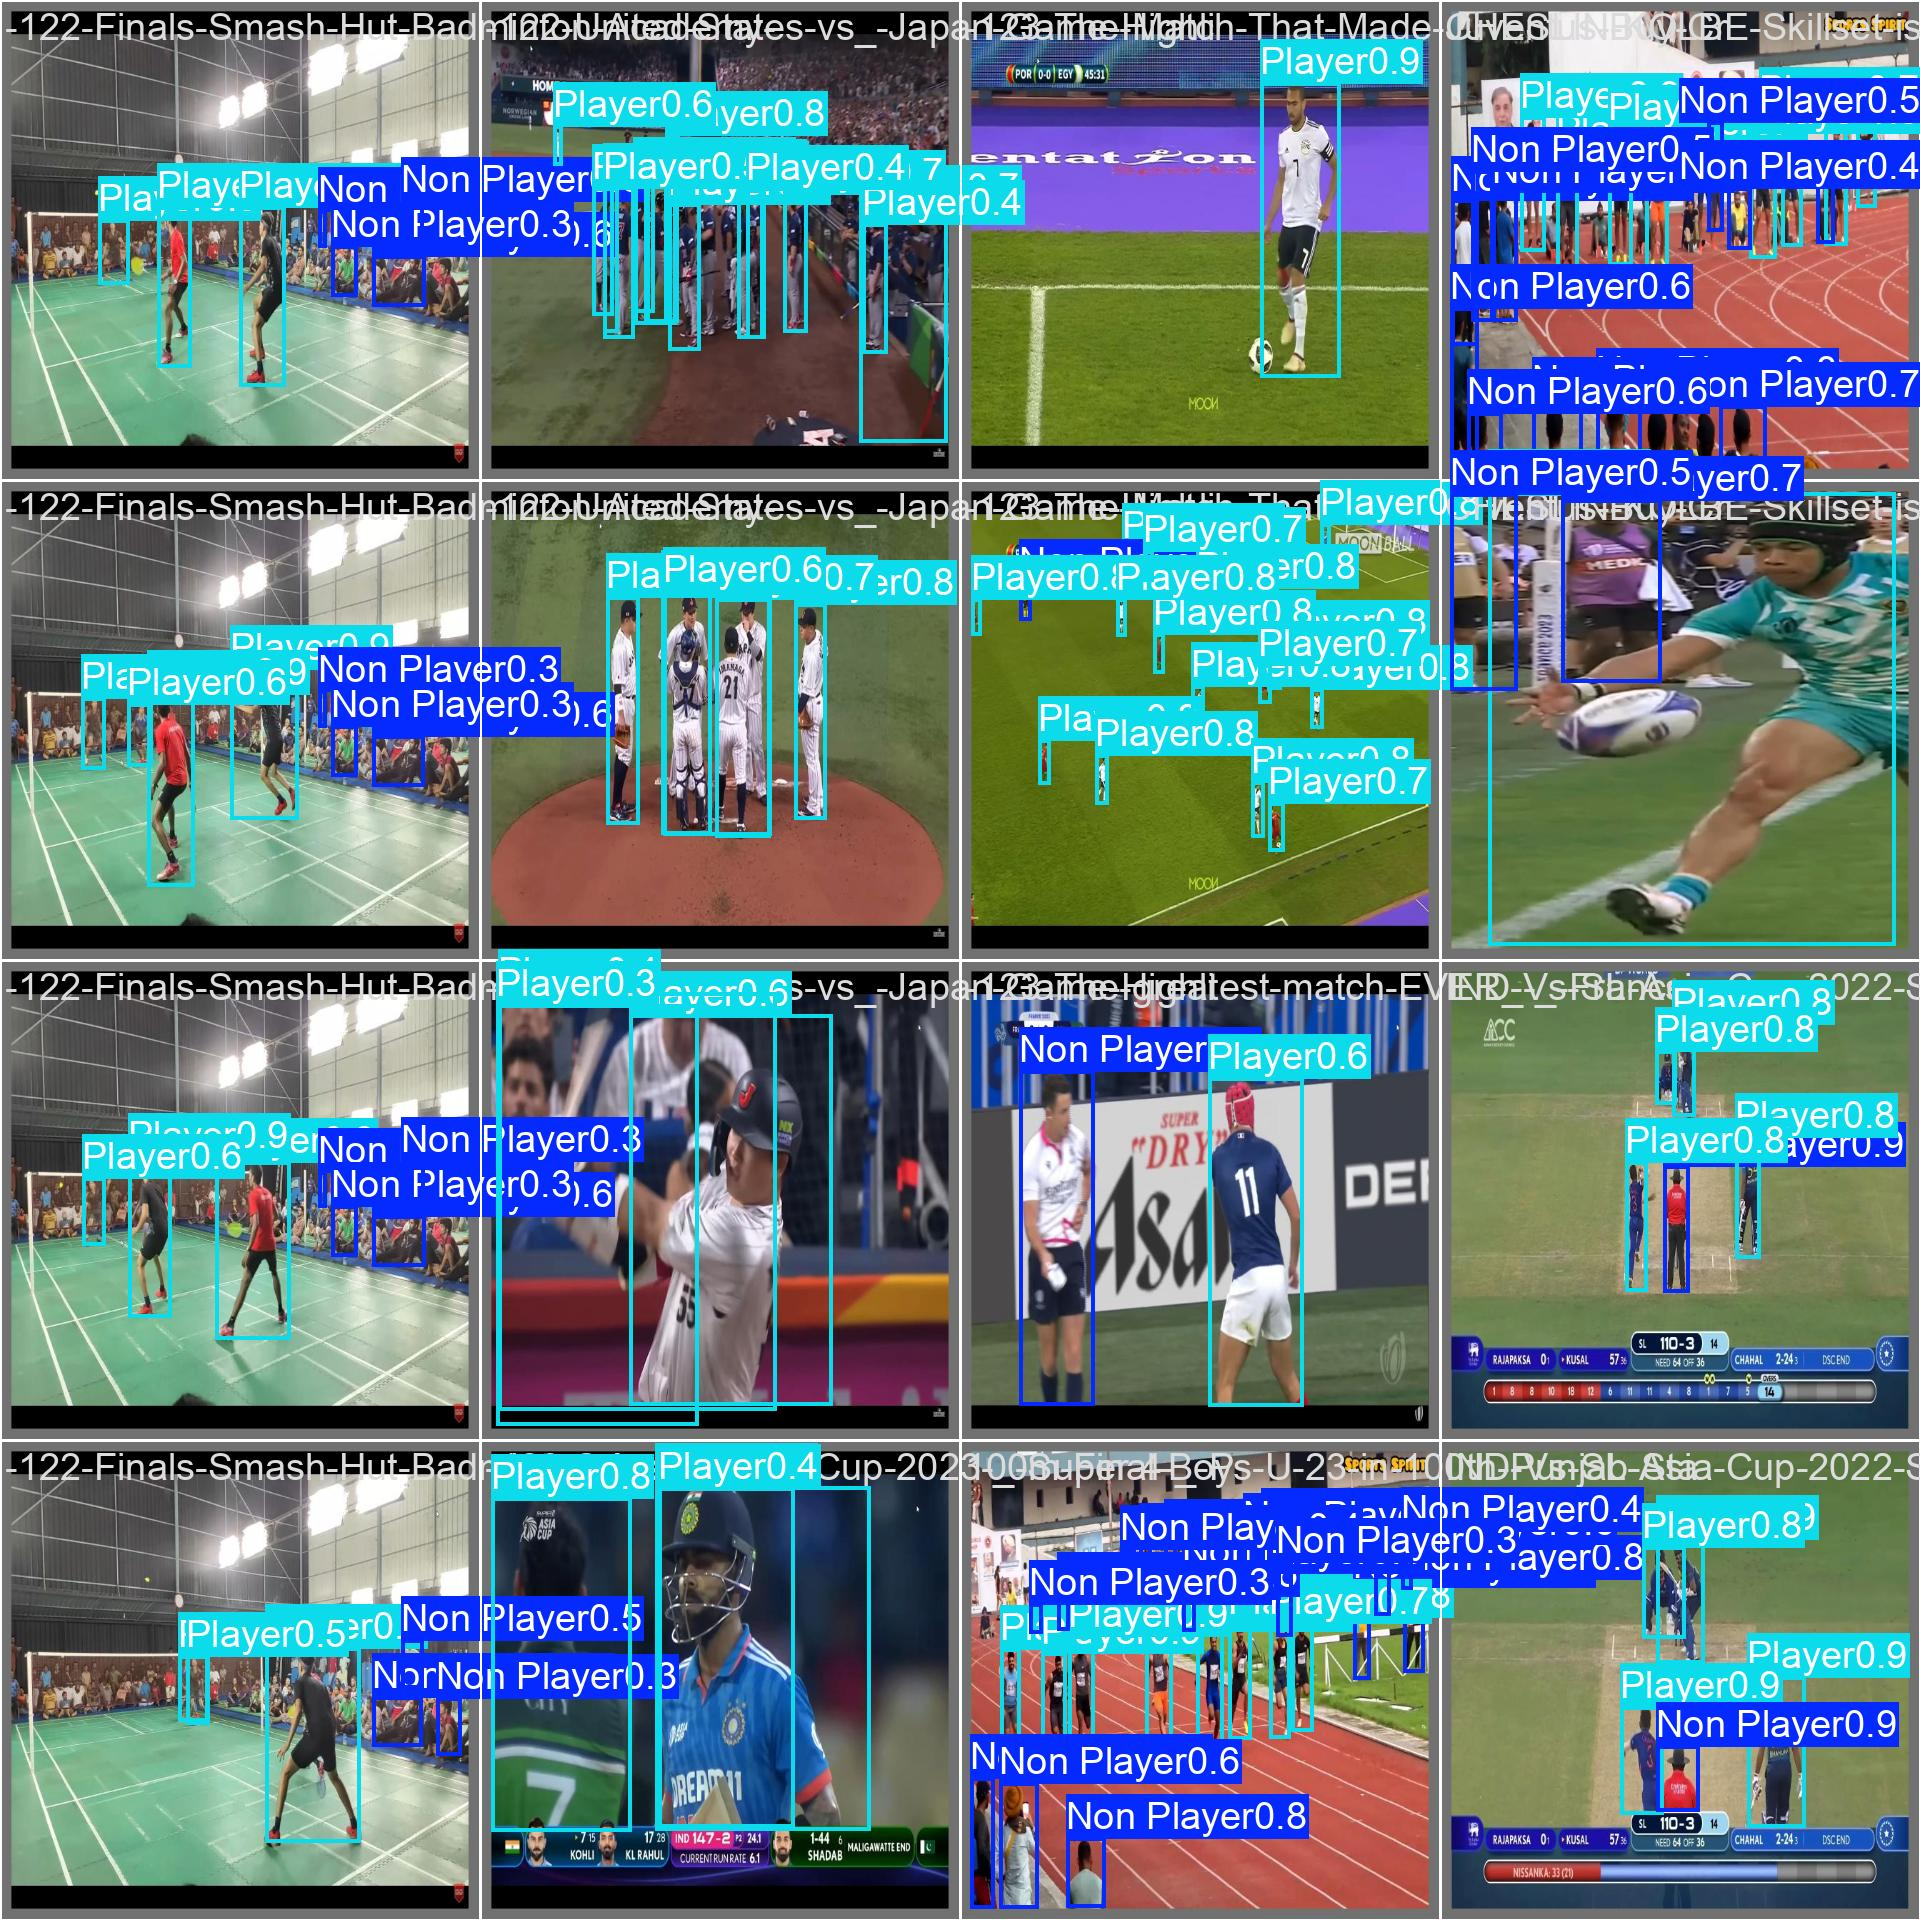


Label Distribution:


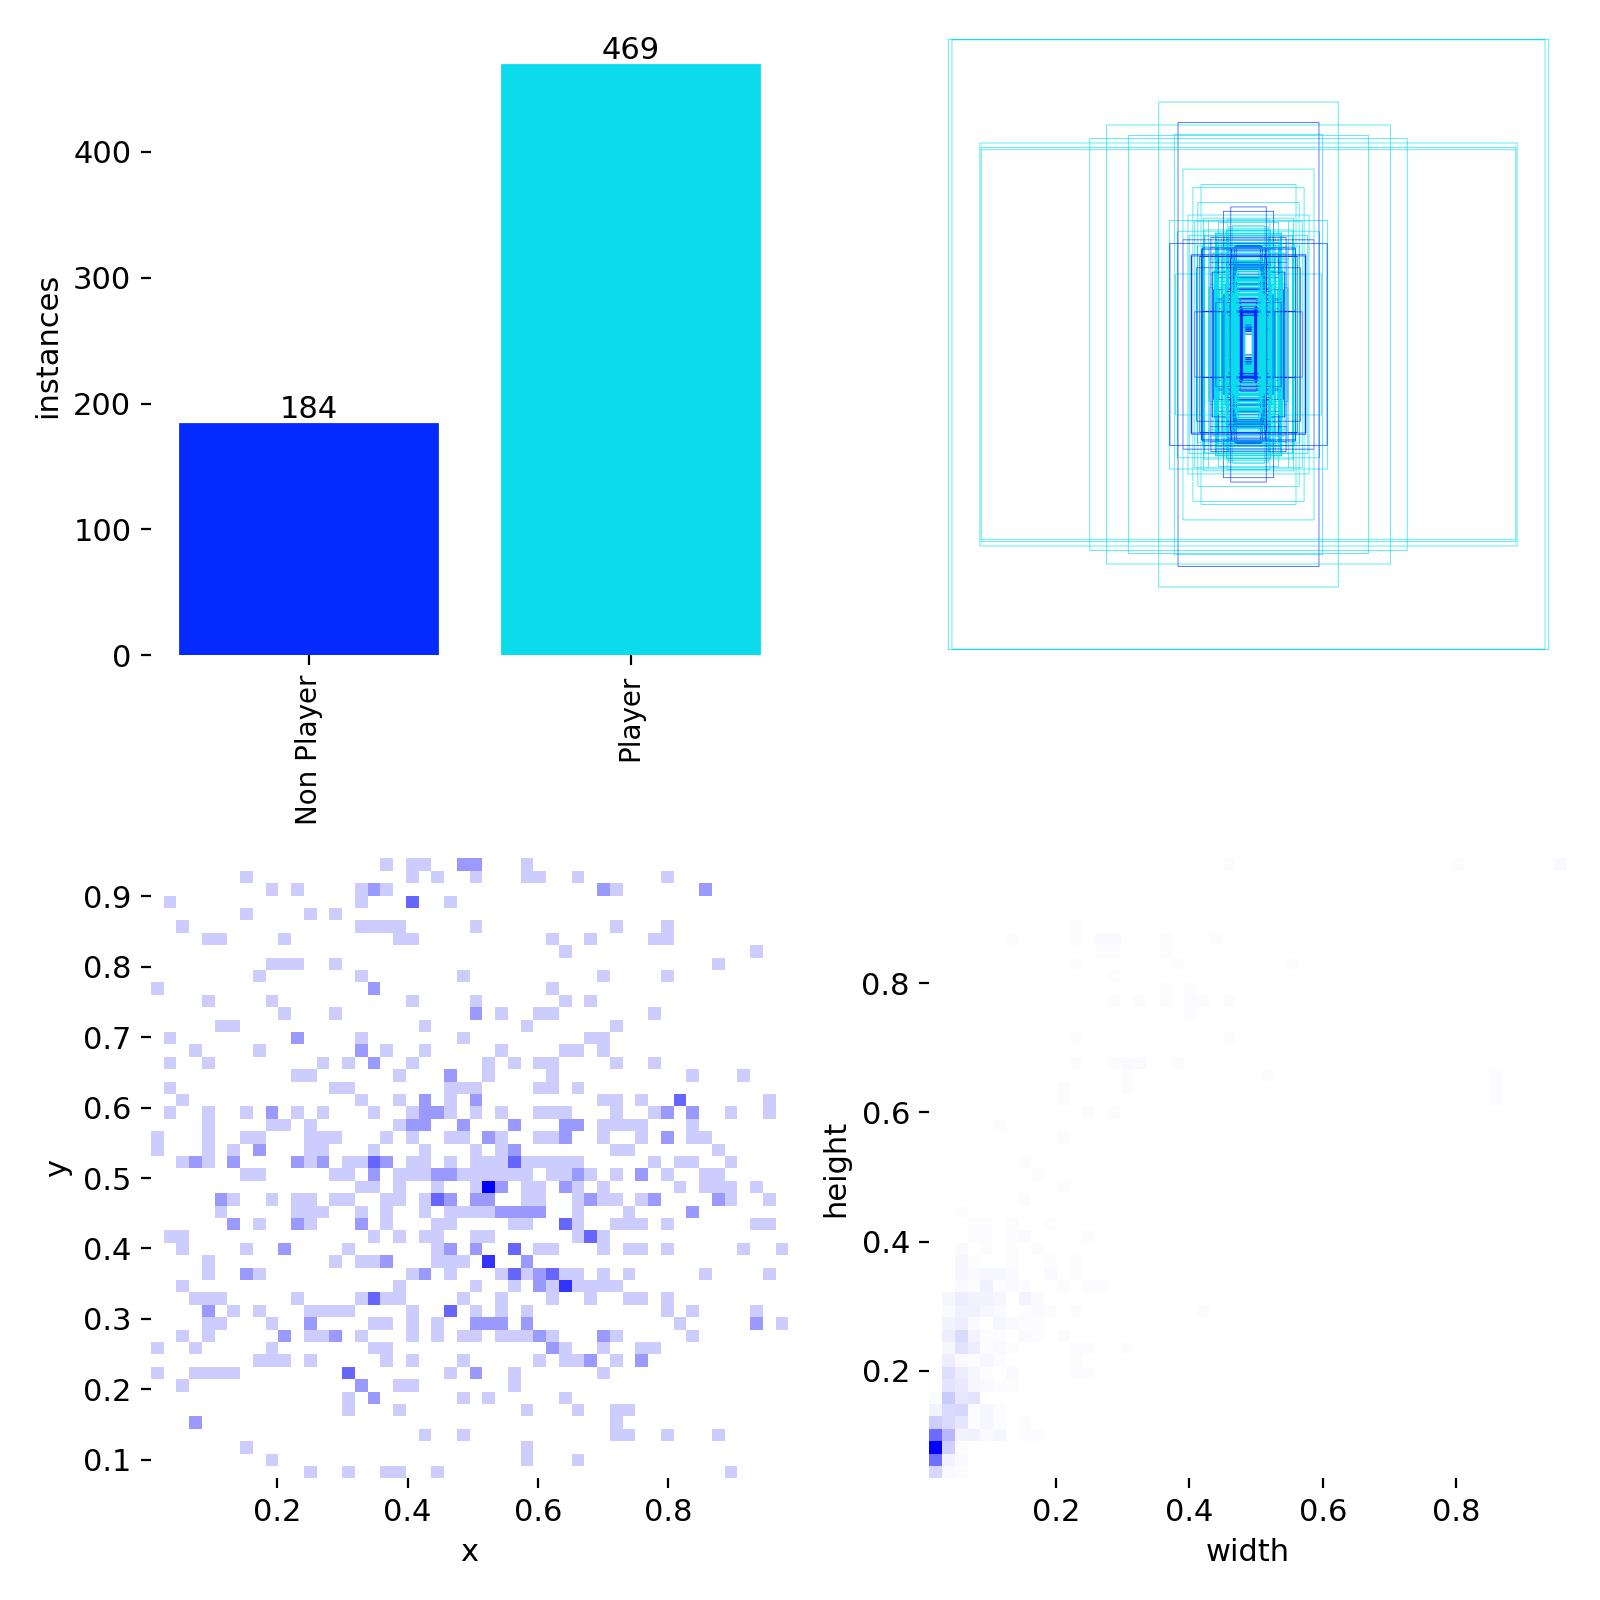

In [52]:
%cd {HOME}

from IPython.display import Image
import os

# Display all results after training completes
results_files = {
    'confusion_matrix.png': 'Confusion Matrix',
    'results.png': 'Training Metrics',
    'val_batch0_pred.jpg': 'Sample Predictions',
    'labels.jpg': 'Label Distribution'
}

for file, description in results_files.items():
    file_path = f'runs/detect/train/{file}'
    if os.path.exists(file_path):
        print(f"\n{description}:")
        display(Image(filename=file_path, width=600))
    else:
        print(f"{file} not found yet")

Ultralytics 8.4.77 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs

image 1/30 /content/DetectPlayers-3/valid/images/-122-Finals-Smash-Hut-Badminton-Academy-Men-Doubles-Tournament-SIDARTH_T-DHILEPAN-vs-SHIJAS-JAISON-YouTube-Google-Chrome-2025-09-19-12-39-53_mp4-0000_jpg.rf.960bef4e4e824128ccd5b7f5d5831554.jpg: 640x640 1 Non Player, 3 Players, 12.2ms
image 2/30 /content/DetectPlayers-3/valid/images/-122-Finals-Smash-Hut-Badminton-Academy-Men-Doubles-Tournament-SIDARTH_T-DHILEPAN-vs-SHIJAS-JAISON-YouTube-Google-Chrome-2025-09-19-12-39-53_mp4-0001_jpg.rf.86722faa070162ccff63103b800424bb.jpg: 640x640 1 Non Player, 3 Players, 12.2ms
image 3/30 /content/DetectPlayers-3/valid/images/-122-Finals-Smash-Hut-Badminton-Academy-Men-Doubles-Tournament-SIDARTH_T-DHILEPAN-vs-SHIJAS-JAISON-YouTube-Google-Chrome-2025-09-19-12-39-53_mp4-0003_jpg.rf.96fb23f49b68ad5ad8eb40a45c67ef2a.jpg: 640x640 1 Non Player, 

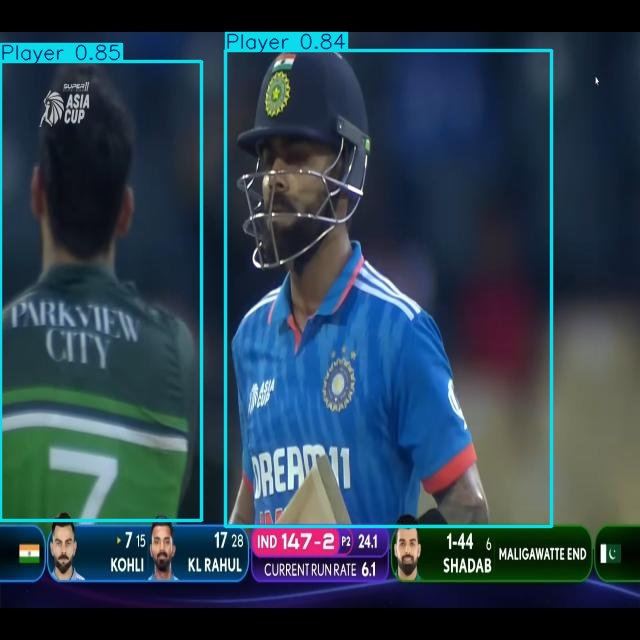

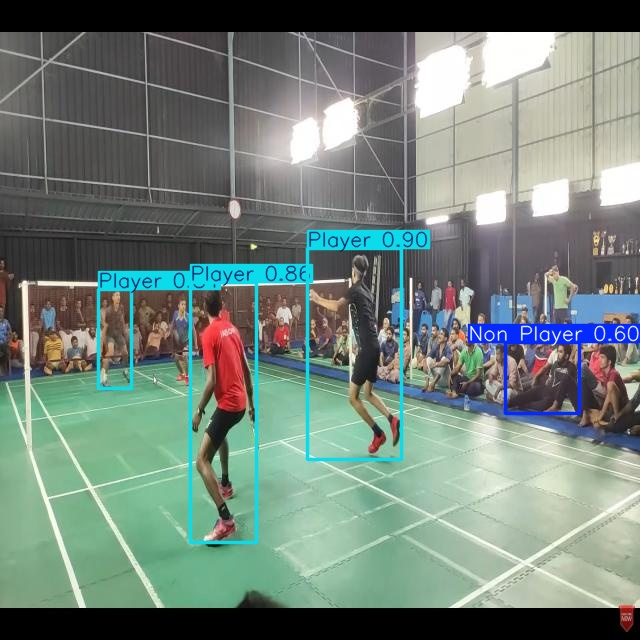

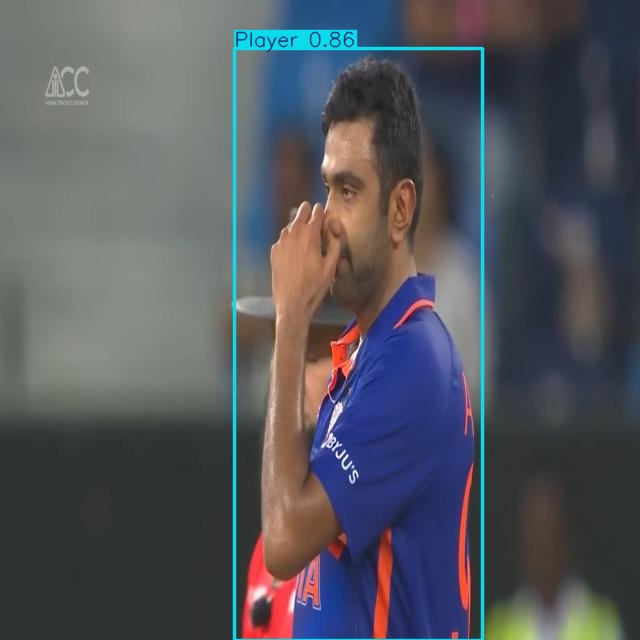

In [9]:
# Test on validation images
!yolo task=detect mode=predict model=runs/detect/train/weights/best.pt source={dataset.location}/valid/images save=True conf=0.5

# Display predictions
from IPython.display import Image
import glob

print("🔍 Sample Predictions on Validation Set:")
predicted_images = glob.glob('runs/detect/predict*/**.jpg')[:3]
for img_path in predicted_images:
    display(Image(filename=img_path, width=500))

In [10]:
# Get detailed performance metrics
!yolo task=detect mode=val model=runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.4.77 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1813.9±337.8 MB/s, size: 44.7 KB)
val: Scanning /content/DetectPlayers-3/valid/labels.cache... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 5.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.6it/s 1.2s
                   all         30        154      0.732      0.738      0.796      0.548
            Non Player         14         39      0.584       0.59      0.654      0.441
                Player         30        115      0.879      0.887      0.938      0.655
Speed: 11.5ms preprocess, 15.8ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /content/runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

In [12]:
# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Read the training results
results_csv = 'runs/detect/train/results.csv'
results_df = pd.read_csv(results_csv)

print("📊 Training Results Summary:")
print(results_df[['epoch', 'train/box_loss', 'val/box_loss', 'metrics/precision(B)',
                   'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)']].tail(10))

📊 Training Results Summary:
    epoch  train/box_loss  val/box_loss  metrics/precision(B)  \
40     41         1.03357       1.17670               0.70634   
41     42         0.98051       1.19526               0.72409   
42     43         0.94058       1.21402               0.75940   
43     44         0.94161       1.18742               0.78533   
44     45         0.91560       1.18723               0.77856   
45     46         0.92528       1.19072               0.77583   
46     47         0.90464       1.18296               0.77925   
47     48         0.87169       1.16517               0.73699   
48     49         0.87661       1.15341               0.72573   
49     50         0.89441       1.14177               0.73146   

    metrics/recall(B)  metrics/mAP50(B)  metrics/mAP50-95(B)  
40            0.80115           0.77460              0.51064  
41            0.70424           0.76518              0.49971  
42            0.66621           0.75969              0.49459  
43  

Found columns:
  Box Loss: val/box_loss
  Precision: metrics/precision(B)
  mAP50-95: metrics/mAP50-95(B)


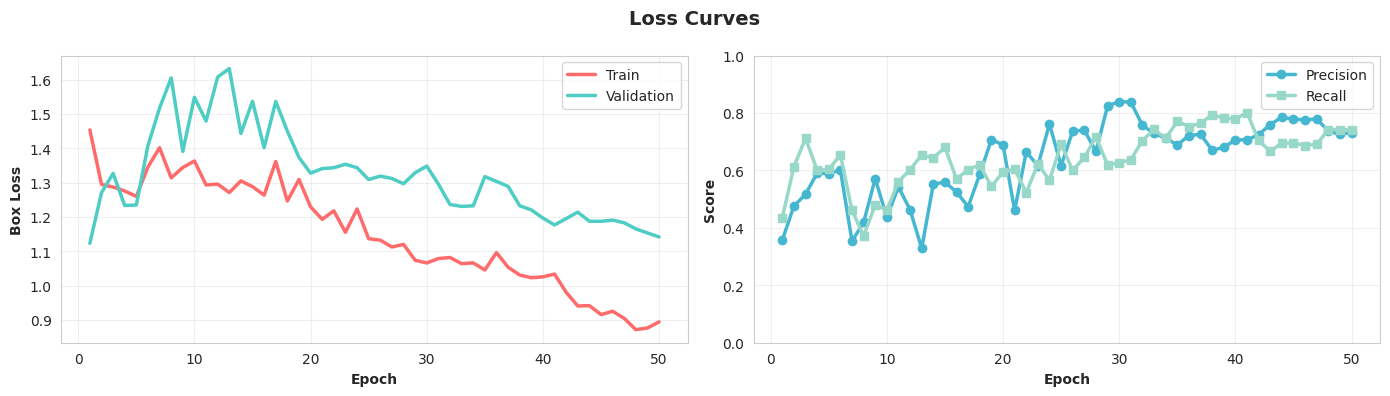


BEST METRICS:
Epoch: 50
Precision: 0.7315
Recall: 0.7415
mAP50-95: 0.5480


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

results_csv = 'runs/detect/train/results.csv'
results_df = pd.read_csv(results_csv)

# Helper function - automatically finds correct column names
def find_column(df, possible_names):
    """Find which column name exists"""
    for name in possible_names:
        if name in df.columns:
            return name
    return None

# Map columns
box_loss_train = find_column(results_df, ['train/box_loss', 'train_loss/box_loss'])
box_loss_val = find_column(results_df, ['val/box_loss', 'val_loss/box_loss'])
precision = find_column(results_df, ['metrics/precision(B)', 'precision'])
recall = find_column(results_df, ['metrics/recall(B)', 'recall'])
map50 = find_column(results_df, ['metrics/mAP50(B)', 'mAP50'])
map50_95 = find_column(results_df, ['metrics/mAP50-95(B)', 'mAP50-95'])
epoch = find_column(results_df, ['epoch', 'Epoch'])

print("Found columns:")
print(f"  Box Loss: {box_loss_val}")
print(f"  Precision: {precision}")
print(f"  mAP50-95: {map50_95}")

# LOSS CURVES
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Loss Curves', fontsize=14, fontweight='bold')

if box_loss_train and box_loss_val:
    axes[0].plot(results_df[epoch], results_df[box_loss_train], label='Train', linewidth=2.5, color='#FF6B6B')
    axes[0].plot(results_df[epoch], results_df[box_loss_val], label='Validation', linewidth=2.5, color='#4ECDC4')
    axes[0].set_xlabel('Epoch', fontweight='bold')
    axes[0].set_ylabel('Box Loss', fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

# METRICS
if precision and recall:
    axes[1].plot(results_df[epoch], results_df[precision], label='Precision', linewidth=2.5, color='#45B7D1', marker='o')
    axes[1].plot(results_df[epoch], results_df[recall], label='Recall', linewidth=2.5, color='#98D8C8', marker='s')
    axes[1].set_xlabel('Epoch', fontweight='bold')
    axes[1].set_ylabel('Score', fontweight='bold')
    axes[1].set_ylim([0, 1])
    axes[1].legend()
    axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('performance_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# SUMMARY
print("\n" + "="*50)
print("BEST METRICS:")
print("="*50)
if map50_95:
    best_idx = results_df[map50_95].idxmax()
    best = results_df.iloc[best_idx]
    print(f"Epoch: {int(best[epoch])}")
    if precision:
        print(f"Precision: {best[precision]:.4f}")
    if recall:
        print(f"Recall: {best[recall]:.4f}")
    if map50_95:
        print(f"mAP50-95: {best[map50_95]:.4f}")
print("="*50)

Saving images5.jpg to images5.jpg
Ultralytics 8.4.77 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs

image 1/1 /content/images5.jpg: 448x640 3 Players, 42.6ms
Speed: 3.3ms preprocess, 42.6ms inference, 16.1ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict-8
💡 Learn more at https://docs.ultralytics.com/modes/predict
Prediction for images5.jpg:


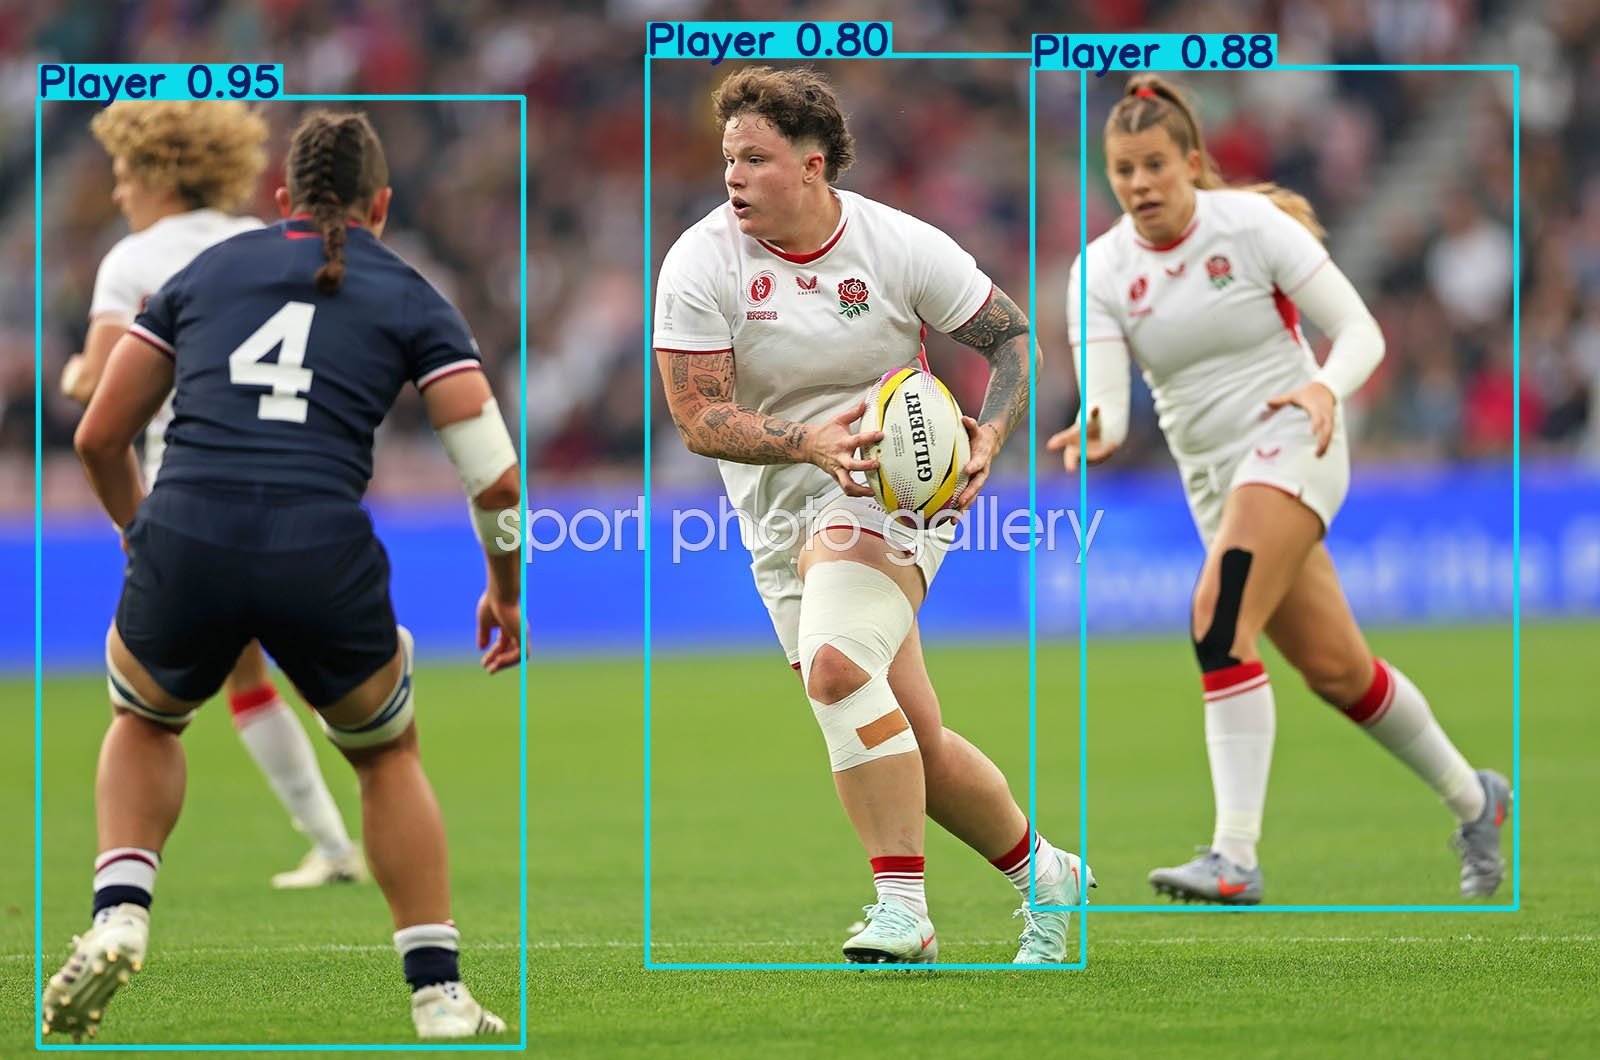

In [36]:
from google.colab import files
from IPython.display import Image
import os
import glob

# Upload images
uploaded = files.upload()

# Test on uploaded images
for filename in uploaded.keys():
    !yolo task=detect mode=predict model=runs/detect/train/weights/best.pt source={filename} save=True

    # Find the latest prediction directory
    prediction_dirs = glob.glob('runs/detect/predict*')
    if prediction_dirs:
        latest_predict_dir = sorted(prediction_dirs)[-1]  # Get most recent
        predicted_image_path = f'{latest_predict_dir}/{filename}'

        if os.path.exists(predicted_image_path):
            print(f"Prediction for {filename}:")
            display(Image(filename=predicted_image_path, width=500))
        else:
            print(f"Predicted image not found at: {predicted_image_path}")
            print(f"Files in {latest_predict_dir}:")
            for file in os.listdir(latest_predict_dir)[:5]:  # Show first 5 files
                print(f"  - {file}")
    else:
        print("No prediction directories found")

In [39]:
from google.colab import files
from IPython.display import HTML, Video
from base64 import b64encode
import os
import glob

# Upload video
print("Upload your video:")
uploaded = files.upload()

# Get the uploaded filename
original_filename = list(uploaded.keys())[0]
print(f"Original filename: {original_filename}")

# Create a clean filename (remove spaces and special characters)
clean_filename = "sport_video.mp4"
os.rename(original_filename, clean_filename)
print(f"Clean filename: {clean_filename}")

# Process the video with your model
!yolo task=detect mode=predict model=runs/detect/train/weights/best.pt source={clean_filename} save=True conf=0.5

# Find the processed video
prediction_dirs = glob.glob('runs/detect/predict*')
if prediction_dirs:
    latest_dir = sorted(prediction_dirs)[-1]
    print(f"Looking in: {latest_dir}")

    # Check what files were created
    print("Files in prediction directory:")
    for file in os.listdir(latest_dir):
        print(f"  - {file}")

    # Look for the output video
    video_files = glob.glob(f'{latest_dir}/*.mp4')

    if video_files:
        output_video = video_files[0]
        print(f"🎬 Success! Processed video: {output_video}")

        # Display the video
        display(Video(output_video, width=600))

        print(f"Video saved at: {output_video}")
    else:
        print("No MP4 output found. The video might still be processing or there was an error.")
else:
    print("No prediction directories found")

Upload your video:


Saving Cricket_new.mp4 to Cricket_new.mp4
Original filename: Cricket_new.mp4
Clean filename: sport_video.mp4
Ultralytics 8.4.77 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs

video 1/1 (frame 1/392) /content/sport_video.mp4: 640x384 1 Player, 67.2ms
video 1/1 (frame 2/392) /content/sport_video.mp4: 640x384 1 Player, 12.1ms
video 1/1 (frame 3/392) /content/sport_video.mp4: 640x384 1 Player, 12.4ms
video 1/1 (frame 4/392) /content/sport_video.mp4: 640x384 1 Player, 11.3ms
video 1/1 (frame 5/392) /content/sport_video.mp4: 640x384 1 Player, 11.1ms
video 1/1 (frame 6/392) /content/sport_video.mp4: 640x384 1 Player, 12.1ms
video 1/1 (frame 7/392) /content/sport_video.mp4: 640x384 1 Player, 12.4ms
video 1/1 (frame 8/392) /content/sport_video.mp4: 640x384 1 Player, 10.6ms
video 1/1 (frame 9/392) /content/sport_video.mp4: 640x384 1 Player, 14.2ms
video 1/1 (frame 10/392) /content/sport_video.mp4:

Loading models...
✓ Models loaded!

Select image(s) to upload:


Saving images2.jpg to images2.jpg

Processing: images2.jpg
📷 Image size: 620x413
🔍 Detecting players...

0: 448x640 3 Players, 14.0ms
Speed: 2.4ms preprocess, 14.0ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)
  ✓ Player 1: Running pose detection...

0: 640x384 2 persons, 7.5ms
Speed: 1.5ms preprocess, 7.5ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 384)
  ✓ Player 2: Running pose detection...

0: 640x288 1 person, 7.4ms
Speed: 2.0ms preprocess, 7.4ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 288)
  ✓ Player 3: Running pose detection...

0: 640x256 1 person, 7.4ms
Speed: 1.7ms preprocess, 7.4ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 256)

✓ Detected 3 players
💾 Saved to: player_pose_results/images2_player_pose.jpg

📊 Result for images2.jpg:


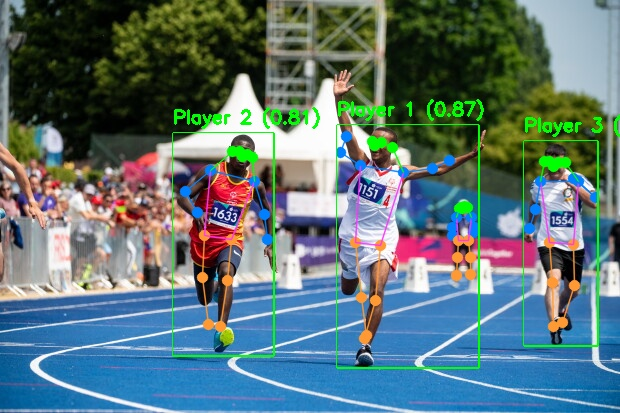



✓ All images processed!
Results saved in: player_pose_results/


In [49]:
from google.colab import files
from IPython.display import Image, display
from ultralytics import YOLO
import cv2
import os
import glob
from pathlib import Path

# Load models
print("Loading models...")
player_model = YOLO("runs/detect/train/weights/best.pt")
pose_model = YOLO("yolov8n-pose.pt")
print("✓ Models loaded!\n")

# Upload images
print("Select image(s) to upload:")
uploaded = files.upload()

# Create output directory
output_dir = "player_pose_results"
os.makedirs(output_dir, exist_ok=True)

# Process each uploaded image
for filename in uploaded.keys():
    print(f"\n{'='*60}")
    print(f"Processing: {filename}")
    print(f"{'='*60}")

    # Read image
    img = cv2.imread(filename)

    if img is None:
        print(f"❌ Error: Could not read {filename}")
        continue

    h, w = img.shape[:2]
    print(f"📷 Image size: {w}x{h}")

    # Create output image
    output_img = img.copy()

    # Detect players
    print("🔍 Detecting players...")
    player_results = player_model(img, conf=0.5)

    player_count = 0

    # Process each detection
    for result in player_results:
        boxes = result.boxes

        if boxes is not None and len(boxes) > 0:
            xyxy = boxes.xyxy.cpu().numpy()
            confs = boxes.conf.cpu().numpy()

            for idx, box in enumerate(xyxy):
                x1, y1, x2, y2 = map(int, box)

                # Bound check
                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(w, x2), min(h, y2)

                box_width = x2 - x1
                box_height = y2 - y1

                if box_width < 20 or box_height < 20:
                    continue

                player_count += 1

                # Draw player bounding box (green)
                cv2.rectangle(output_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                label = f"Player {player_count} ({confs[idx]:.2f})"
                cv2.putText(output_img, label, (x1, y1-10),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

                # Crop and run pose detection
                player_crop = img[y1:y2, x1:x2]

                if player_crop.size > 0:
                    print(f"  ✓ Player {player_count}: Running pose detection...")
                    pose_results = pose_model(player_crop, conf=0.3)

                    if len(pose_results) > 0 and pose_results[0].keypoints is not None:
                        pose_img = pose_results[0].plot(
                            boxes=False,
                            line_width=2,
                            probs=False
                        )
                        pose_img = cv2.resize(pose_img, (box_width, box_height))
                        output_img[y1:y2, x1:x2] = pose_img

    print(f"\n✓ Detected {player_count} players")

    # Save result
    output_filename = f"{output_dir}/{Path(filename).stem}_player_pose.jpg"
    cv2.imwrite(output_filename, output_img)
    print(f"💾 Saved to: {output_filename}\n")

    # Display result
    print(f"📊 Result for {filename}:")
    display(Image(filename=output_filename, width=600))
    print()

print(f"\n{'='*60}")
print("✓ All images processed!")
print(f"Results saved in: {output_dir}/")
print(f"{'='*60}")